# ReasonForge

Deterministic math & code tools for small language models.

1. Clone repo & install deps
2. Install Ollama & pull model
3. Sanity tests
4. MATH-500 / HumanEval benchmarks
5. Gradio chat UI

---
## Setup

In [1]:
# Clone repo & install deps
!git clone https://github.com/RoyCoding8/ReasonForge-MCP-Server.git /content/MCP
!pip uninstall -y -q omegaconf
!pip install -q "gradio>=6.0" sympy datasets "math-verify[antlr4_13_2]" pandas matplotlib

Cloning into '/content/MCP'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 41 (delta 1), reused 41 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 108.34 KiB | 1.90 MiB/s, done.
Resolving deltas: 100% (1/1), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.2/24.2 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 17.1 MB/s eta 0:00:00


In [2]:
# Install Ollama
!sudo apt-get install -qq zstd
!curl -fsSL https://ollama.com/install.sh | sh > /dev/null 2>&1

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [3]:
from google.colab import drive
drive.mount('/content/drive')

RESULTS_DIR = '/content/drive/MyDrive/ReasonForge/results'
!mkdir -p {RESULTS_DIR}

Mounted at /content/drive


In [4]:
import subprocess, time, os, requests
from pathlib import Path
import json as _json

MODELS_PATH = '/content/ollama_models'
os.makedirs(MODELS_PATH, exist_ok=True)

# I am using G4 GPU with ~96GB VRAM, adjust values according to your GPU
MODEL_CONFIG = {
    'qwen3:8b':  15
    # 'qwen3:32b': 7
}

In [5]:
# Helper functions
def start_ollama(num_parallel=None, timeout=30):
    subprocess.run(['pkill', '-f', 'ollama'], capture_output=True)
    time.sleep(2)

    env = os.environ.copy()
    env['OLLAMA_MODELS'] = MODELS_PATH
    env['OLLAMA_HOST'] = '0.0.0.0:11434'
    if num_parallel is not None:
        env['OLLAMA_NUM_PARALLEL'] = str(num_parallel)

    log_file = open('/content/ollama_server.log', 'a')
    subprocess.Popen(
        ['ollama', 'serve'],
        env=env,
        stdout=log_file,
        stderr=subprocess.STDOUT,
    )

    start = time.time()
    while time.time()-start < timeout:
        try:
            requests.get('http://localhost:11434/')
            print(f'Ollama ready ({time.time()-start:.2f}s)',
                  f'  parallel={num_parallel}' if num_parallel else '')
            return True
        except requests.ConnectionError:
            time.sleep(1)
    print('Ollama failed to start — check /content/ollama_server.log')
    return False


def run_benchmark_suite(benchmark_module, n, skip_baseline, think, seed=42):
    os.chdir('/content/MCP')
    for model, num_parallel in MODEL_CONFIG.items():
        start_ollama(num_parallel)
        print(f'\n{'-'*56}')
        print(f'  {model}  (parallel={num_parallel})')
        cmd = f'python -m {benchmark_module} --model {model} --n {n} --seed {seed}'
        cmd += f' --results-dir {RESULTS_DIR}'
        if skip_baseline: cmd += ' --skip-baseline'
        if think: cmd += ' --think'
        !{cmd}


def load_latest_result(glob_pattern='*.json'):
    results_path = Path(RESULTS_DIR)
    files = sorted(results_path.glob(glob_pattern), key=lambda f: f.stat().st_mtime)
    if not files:
        print(f'No results matching {glob_pattern!r}. Run the benchmark first.')
        return None, None
    latest = files[-1]
    print(f'Loading: {latest.name}\n')
    with open(latest) as f:
        report = _json.load(f)
    return report, latest


def print_report_header(report, accuracy_key='rf_accuracy', baseline_key='baseline_accuracy', delta_key='delta'):
    print(f"Model: {report['model']}  |  N={report['n']}  |  Seed={report['seed']}")
    print(f"{accuracy_key.replace('_',' ').title()}: {report[accuracy_key]:.1%}")
    if report.get(baseline_key) is not None:
        print(f"{baseline_key.replace('_',' ').title()}: {report[baseline_key]:.1%}")
        print(f"Delta: {report[delta_key]:+.1%}")
    print()

In [6]:
start_ollama()

Ollama ready (1.00s) 


True

In [7]:
for model in MODEL_CONFIG:
    print(f'Pulling {model}...')
    !OLLAMA_MODELS={MODELS_PATH} ollama pull {model}
print('All models pulled.')

Pulling qwen3:8b...

All models pulled.


---
## Benchmarks

A/B comparison: Baseline (no tools) vs ReasonForge (with tools).

Results are checkpointed to Google Drive after each problem. If the notebook crashes, re-running will resume from where it left off.

In [8]:
# MATH-500 Benchmark
N_MATH = 50
SKIP_BASELINE = False
THINK = True

from google.colab import userdata
try: os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
except: print('HF_TOKEN not found in Secrets.')

run_benchmark_suite('tests.math_benchmark', N_MATH, SKIP_BASELINE, THINK, seed=42)

Ollama ready (1.00s)   parallel=15

--------------------------------------------------------
  qwen3:8b  (parallel=15)
  ReasonForge A/B Benchmark — qwen3:8b
  50 problems · seed=42
--------------------------------------------------------

README.md: 4.82kB [00:00, 15.6MB/s]
data/train-00000-of-00001-7320a6f3aba8eb(…): 100% 4.85M/4.85M [00:01<00:00, 2.50MB/s]
Generating train split: 100% 12500/12500 [00:00<00:00, 311595.81 examples/s]
 12500 problems
  Resuming: 50/50 already completed

  [ 1/50] Intermediate Algebra L4  B:✓ RF:✓ R1  B:87.0s RF:60.3s  (cached)
  [ 2/50] Counting & Probability L4  B:✓ RF:✓ R1  B:13.7s RF:6.8s  (cached)
  [ 3/50] Algebra              L5  B:✗ RF:✗ R1  B:31.2s RF:14.2s  (cached)
  [ 4/50] Precalculus          L3  B:✓ RF:✓ R1  B:88.9s RF:65.9s  (cached)
  [ 5/50] Intermediate Algebra L1  B:✓ RF:✓ R1  B:14.8s RF:5.2s  (cached)
  [ 6/50] Intermediate Algebra L1  B:✓ RF:✓ T R2  B:14.5s RF:11.4s  (cached)
  [ 7/50] Intermediate Algebra L1  B:✓ RF:✓ R1  B:13.8s 

Loading: math_qwen3_8b_20260302_220642.json

Model: qwen3:8b  |  N=50  |  Seed=42
Rf Accuracy: 90.0%
Baseline Accuracy: 86.0%
Delta: +4.0%



,type,level,expected,baseline_answer,baseline_correct,rf_answer,rf_correct,rf_rounds,rf_used_tools,weight
0,Intermediate Algebra,Level 4,49,49,True,49,True,1,False,4
1,Counting & Probability,Level 4,5,5,True,5,True,1,False,4
2,Algebra,Level 5,"6, 8\text{, and }10","6,8,10",False,"6, 8, 10",False,1,False,5
3,Precalculus,Level 3,4,4,True,4,True,1,False,3
4,Intermediate Algebra,Level 1,"-3,1,5",5,True,"-3,1,5",True,1,False,1
5,Intermediate Algebra,Level 1,16,16,True,16,True,2,True,1
6,Intermediate Algebra,Level 1,-16,-16,True,-16,True,1,False,1
7,Counting & Probability,Level 5,438,438,True,438,True,2,True,5
8,Precalculus,Level 5,432,1296,False,432,True,1,False,5
9,Algebra,Level 3,-15,-15,True,-15,True,1,False,3


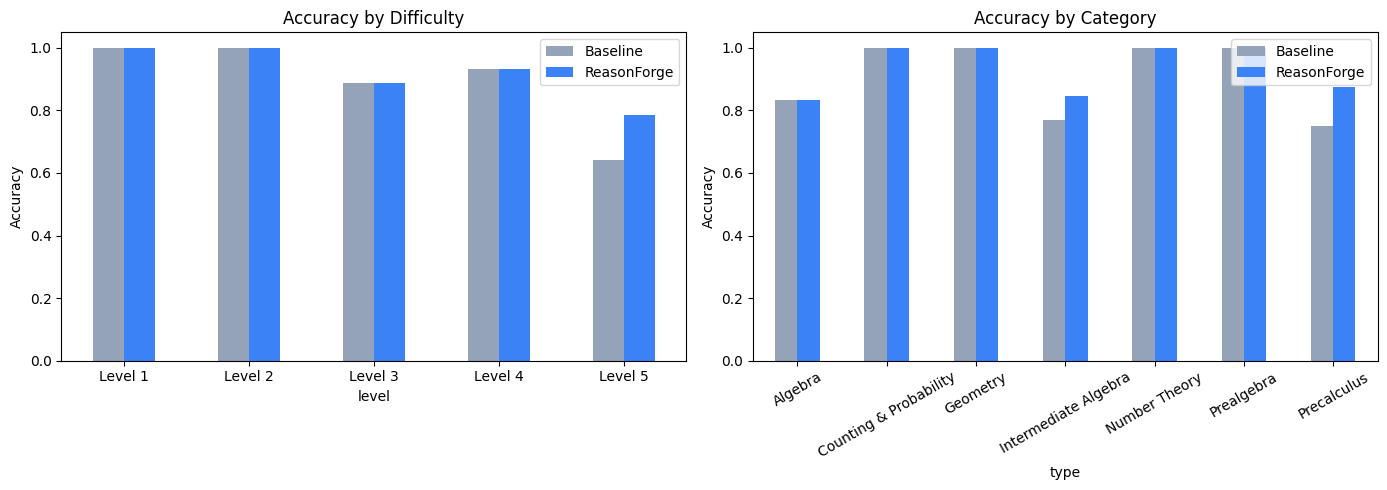

In [9]:
# Visualize MATH-500 results
import pandas as pd, matplotlib.pyplot as plt

report, _ = load_latest_result('*.json')
if report:
    print_report_header(report, 'rf_accuracy', 'baseline_accuracy')
    df = pd.DataFrame(report['results'])
    display(df[['type','level','expected','baseline_answer','baseline_correct','rf_answer','rf_correct','rf_rounds','rf_used_tools','weight']])

    # By difficulty
    if 'baseline_correct' in df.columns and df['baseline_correct'].any():
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        lvl = df.groupby('level').agg(Baseline=('baseline_correct','mean'), ReasonForge=('rf_correct','mean')).sort_index()
        lvl.plot.bar(ax=axes[0], rot=0, color=['#94a3b8','#3b82f6'])
        axes[0].set_title('Accuracy by Difficulty')
        axes[0].set_ylabel('Accuracy')
        axes[0].set_ylim(0, 1.05)
        axes[0].legend(loc='upper right')

        cat = df.groupby('type').agg(Baseline=('baseline_correct','mean'), ReasonForge=('rf_correct','mean')).sort_index()
        cat.plot.bar(ax=axes[1], rot=30, color=['#94a3b8','#3b82f6'])
        axes[1].set_title('Accuracy by Category')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim(0, 1.05)
        axes[1].legend(loc='upper right')

        plt.tight_layout()
        plt.savefig(f'{RESULTS_DIR}/math_results.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(7, 5))
        lvl = df.groupby('level')['rf_correct'].mean().sort_index()
        lvl.plot.bar(ax=ax, rot=0, color='#3b82f6')
        ax.set_title('ReasonForge Accuracy by Difficulty')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1.05)
        plt.tight_layout()
        plt.savefig(f'{RESULTS_DIR}/math_results.png', dpi=150, bbox_inches='tight')
        plt.show()

In [10]:
# HumanEval Code Benchmark
N_CODE = 160
SKIP_BASELINE_CODE = False
THINK_CODE = True

run_benchmark_suite('tests.code_benchmark', N_CODE, SKIP_BASELINE_CODE, THINK_CODE, seed=42)

Ollama ready (1.00s)   parallel=15

--------------------------------------------------------
  qwen3:8b  (parallel=15)
  ReasonForge A/B Code Benchmark — qwen3:8b
  160 problems · seed=42
--------------------------------------------------------

README.md: 6.52kB [00:00, 22.5MB/s]
openai_humaneval/test-00000-of-00001.par(…): 100% 83.9k/83.9k [00:00<00:00, 342kB/s]
Generating test split: 100% 164/164 [00:00<00:00, 65579.74 examples/s]
 164 problems
  Resuming: 160/160 already completed

  [  1/160] HumanEval/163  B:✗ RF:✗ R1  B:17.1s RF:18.6s  (cached)
  [  2/160] HumanEval/28  B:✗ RF:✗ T R3  B:2.2s RF:4.3s  (cached)
  [  3/160] HumanEval/6  B:✗ RF:✓ R1  B:10.7s RF:9.5s  (cached)
  [  4/160] HumanEval/70  B:✗ RF:✓ T R3  B:16.6s RF:18.6s  (cached)
  [  5/160] HumanEval/62  B:✗ RF:✓ R1  B:9.0s RF:20.7s  (cached)
  [  6/160] HumanEval/57  B:✗ RF:✓ R1  B:12.9s RF:10.8s  (cached)
  [  7/160] HumanEval/35  B:✗ RF:✗ R1  B:3.4s RF:4.5s  (cached)
  [  8/160] HumanEval/26  B:✗ RF:✗ T R2  B:15.4s 

Loading: code_qwen3_8b_20260302_220648.json

Model: qwen3:8b  |  N=160  |  Seed=42
Rf Pass1: 63.7%
Baseline Pass1: 2.5%
Delta: +61.3%



,model,task_id,baseline_passed,rf_passed,rf_rounds,rf_used_tools,baseline_time_s,rf_time_s,seed,index
0,qwen3:8b,HumanEval/163,False,False,1,False,17.1,18.6,42,0
1,qwen3:8b,HumanEval/28,False,False,3,True,2.2,4.3,42,1
2,qwen3:8b,HumanEval/6,False,True,1,False,10.7,9.5,42,2
3,qwen3:8b,HumanEval/70,False,True,3,True,16.6,18.6,42,3
4,qwen3:8b,HumanEval/62,False,True,1,False,9.0,20.7,42,4
...,...,...,...,...,...,...,...,...,...,...
155,qwen3:8b,HumanEval/137,False,True,1,False,22.9,25.3,42,155
156,qwen3:8b,HumanEval/11,False,True,1,False,17.6,8.8,42,156
157,qwen3:8b,HumanEval/88,False,True,1,False,15.8,18.2,42,157
158,qwen3:8b,HumanEval/130,False,False,1,False,66.7,60.4,42,158


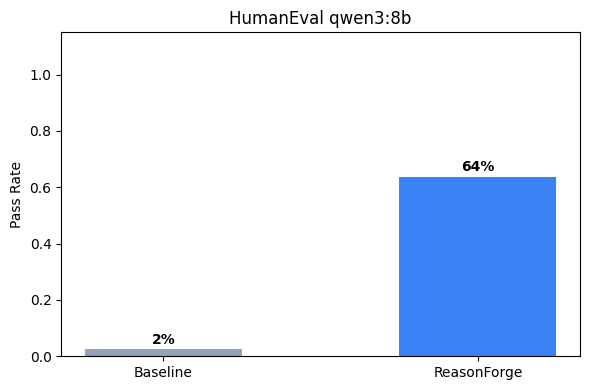

In [11]:
# Visualize HumanEval results
import pandas as pd, matplotlib.pyplot as plt

report, _ = load_latest_result('code_*.json')
if report:
    print_report_header(report, 'rf_pass1', 'baseline_pass1')
    df = pd.DataFrame(report['results'])
    display(df)

    fig, ax = plt.subplots(figsize=(6, 4))
    labels = ['ReasonForge']
    vals = [report['rf_pass1']]
    colors = ['#3b82f6']
    if report.get('baseline_pass1') is not None:
        labels.insert(0, 'Baseline')
        vals.insert(0, report['baseline_pass1'])
        colors.insert(0, '#94a3b8')
    bars = ax.bar(labels, vals, color=colors, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Pass Rate')
    ax.set_title(f'HumanEval {report["model"]}')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/code_results.png', dpi=150, bbox_inches='tight')
    plt.show()

---

In [ ]:
# App Launch
os.environ['RF_SHARE'] = '1'
os.chdir('/content/MCP')

!python -u -m ui.app | tee -a /content/ollama_server.log

---

In [ ]:
# !OLLAMA_MODELS=$MODELS_PATH ollama ps
# print()
# !OLLAMA_MODELS=$MODELS_PATH ollama list

In [ ]:
# !rm -rf /content/MCP
# !rm /content/ollama_server.log